In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1762256644.383926  701301 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [6]:
print(gender_predictions)

[[7.7384239e-04]
 [7.8950549e-04]
 [1.0120951e-03]
 ...
 [9.9847502e-01]
 [9.9787855e-01]
 [9.9846315e-01]]


In [10]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 721 female samples.


In [11]:
df.shape

(721, 196)

In [12]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489,0,1,2
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258,0,1,2
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748,0,1,2
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018,0,1,2
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [13]:
data.iloc[:,-3] == 0

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [14]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [15]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [16]:
y

60      1
61      1
62      1
63      1
64      2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 721, dtype: int64

In [17]:
X_speaker

60       2
61       2
62       2
63       2
64       2
        ..
1435    24
1436    24
1437    24
1438    24
1439    24
Name: speaker, Length: 721, dtype: int64

In [18]:
X.shape, y.shape

((721, 193), (721,))

In [19]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [20]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
559,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.098972,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109
1317,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.122013,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141
197,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,17.673749,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227
185,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,17.221955,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621
201,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,16.753707,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,15.628375,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380
226,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.029112,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313
570,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,17.162428,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735
915,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,15.592766,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849


In [21]:
X_speaker

559     10
1317    22
197      4
185      4
201      4
        ..
191      4
226      4
570     10
915     16
222      4
Name: speaker, Length: 721, dtype: int64

In [22]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [23]:
y1

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(721, 8))

In [24]:
X.shape, y1.shape

((721, 193), (721, 8))

In [25]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [26]:
X2.shape, X2_speaker.shape, y2.shape

((721, 193), (721,), (721,))

In [27]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [28]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [29]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.098972,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109
1,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.122013,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141
2,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,17.673749,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227
3,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,17.221955,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621
4,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,16.753707,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,15.628375,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380
717,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.029112,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313
718,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,17.162428,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735
719,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,15.592766,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849


In [30]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,10
1,22
2,4
3,4
4,4
...,...
716,4
717,4
718,10
719,16


In [31]:
speakers = X_speaker.unique()
speakers

array([10, 22,  4,  8, 12, 18, 14, 16,  2, 24,  6, 20, 19])

In [32]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,10
1,22
2,4
3,4
4,4
...,...
716,4
717,4
718,10
719,16


In [33]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109,10
1,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141,22
2,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227,4
3,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621,4
4,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380,4
717,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313,4
718,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735,10
719,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849,16


In [34]:
# Get random 5 speakers

speaker_counts = X_combined['speaker'].value_counts()
total_speakers = speaker_counts.head(12).index.to_numpy()
selected_speakers = np.random.choice(total_speakers, size=5, replace=False)

print("Selected speakers:", selected_speakers)

Selected speakers: [ 8  4 14 20 12]


In [35]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=720
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_female'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 8
Train speakers: [ 2  4  6 10 12 14 16 18 19 20 22 24]
No overlap in fold 0.
Top 125 features: [  0   2   1   7   6   5  79  81 163 141] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.1710 - loss: 2.1992 - val_accuracy: 0.1500 - val_loss: 2.0686
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.2526 - loss: 1.9194 - val_accuracy: 0.1333 - val_loss: 2.0763
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3298 - loss: 1.7725 - val_accuracy: 0.1333 - val_loss: 2.0777
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3918 - loss: 1.6492 - val_accuracy: 0.1500 - val_loss: 2.0771
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4463 - loss: 1.5560 - val_accuracy: 0.1833 - val_loss: 2.0804
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4856 - loss: 1.4984 - val_accuracy: 0.1500 - val_loss: 2.0839
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5250 - loss: 1.4189 - val_accuracy: 0.2000 - val_loss: 2.0920
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5416 - loss: 1.3941 - val_accuracy: 0.1833 - val_l

Fold 0 Test Accuracy: 0.5500

===== Fold 1 =====
Test speaker: 4
Train speakers: [ 2  6  8 10 12 14 16 18 19 20 22 24]
No overlap in fold 1.
Top 125 features: [  0   2   1   7   6   5  84  35 164 129] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.1876 - loss: 2.1466 - val_accuracy: 0.2000 - val_loss: 2.0571
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.3238 - loss: 1.8295 - val_accuracy: 0.1667 - val_loss: 2.0650
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3555 - loss: 1.7203 - val_accuracy: 0.2000 - val_loss: 2.0714
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.4115 - loss: 1.5938 - val_accuracy: 0.1500 - val_loss: 2.0831
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.4826 - loss: 1.5036 - val_accuracy: 0.1667 - val_loss: 2.0918
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4856 - loss: 1.4883 - val_accuracy: 0.1667 - val_loss: 2.1046
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5144 - loss: 1.4033 - val_accuracy: 0.1833 - val_loss: 2.1166
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5628 - loss: 1.3852 - val_accuracy: 0.

Fold 3 Test Accuracy: 0.4667

===== Fold 4 =====
Test speaker: 12
Train speakers: [ 2  4  6  8 10 14 16 18 19 20 22 24]
No overlap in fold 4.
Top 125 features: [  0   2   1   7   5   6 119  66 168 141] ...


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.1694 - loss: 2.2474 - val_accuracy: 0.1333 - val_loss: 2.0782
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2935 - loss: 1.8936 - val_accuracy: 0.1333 - val_loss: 2.0843
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.3570 - loss: 1.7225 - val_accuracy: 0.1667 - val_loss: 2.0962
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4009 - loss: 1.6040 - val_accuracy: 0.2000 - val_loss: 2.1152
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.4523 - loss: 1.5743 - val_accuracy: 0.0833 - val_loss: 2.1357
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5008 - loss: 1.4698 - val_accuracy: 0.1000 - val_loss: 2.1575
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5204 - loss: 1.4339 - val_accuracy: 0.1000 - val_loss: 2.1754
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5446 - loss: 1.4103 - val_accuracy: 0.

Fold 4 Test Accuracy: 0.4333

===== Cross-validation results =====
Fold 0: Loss=1.7158, Accuracy=0.5500
Fold 1: Loss=2.0384, Accuracy=0.3500
Fold 2: Loss=1.5263, Accuracy=0.5500
Fold 3: Loss=1.6398, Accuracy=0.4667
Fold 4: Loss=1.7464, Accuracy=0.4333

Average accuracy: 0.4700


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'ravdess_speaker_female'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


2025-11-10 18:14:25.677311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 18:14:25.708863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 18:14:26.370207: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 55.00%
Fold 1: Accuracy = 35.00%
Fold 2: Accuracy = 55.00%
Fold 3: Accuracy = 46.67%
Fold 4: Accuracy = 43.33%

Mean Accuracy: 47.00%
SD Accuracy: 7.56
95% CI: [40.38%, 53.62%]


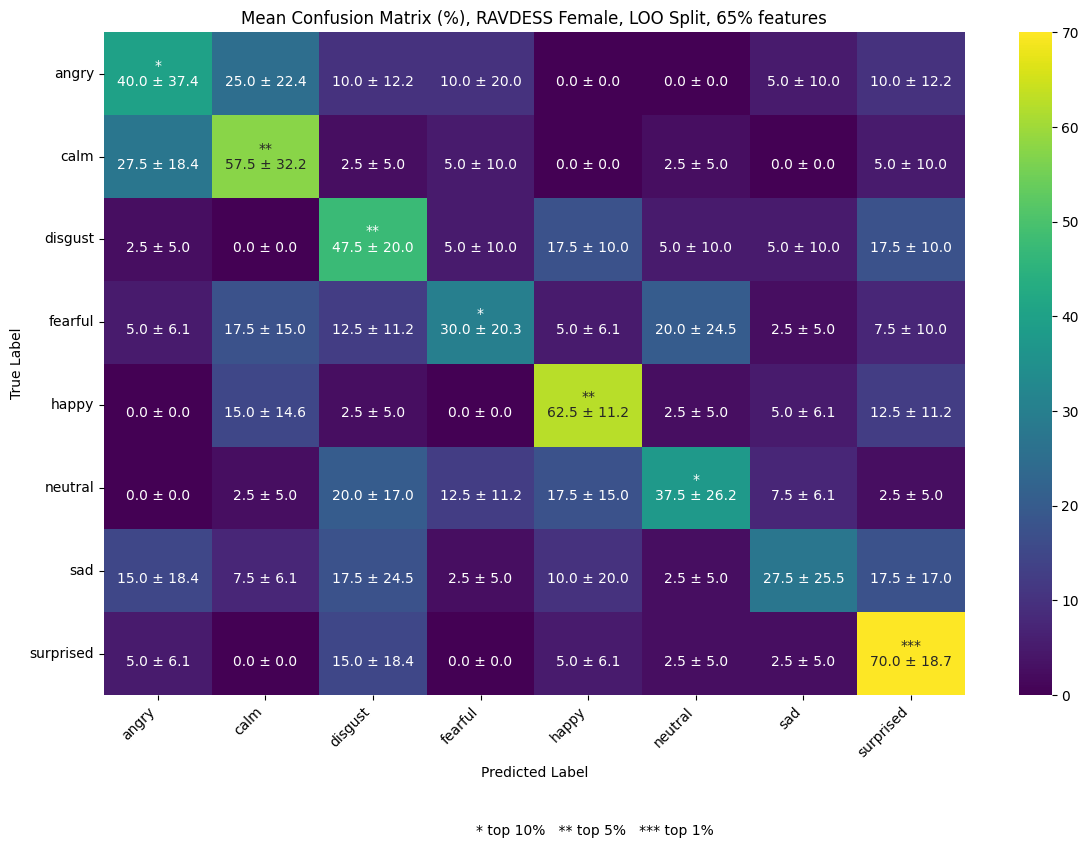

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_speaker_female.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), RAVDESS Female, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
